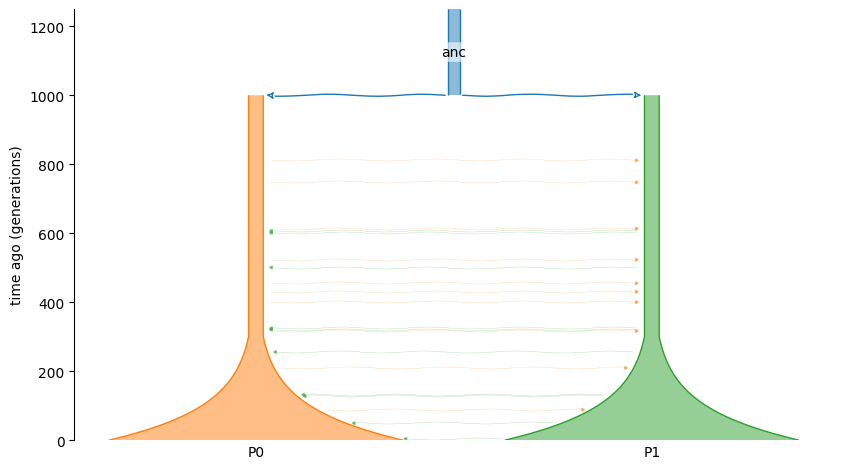

In [1]:
import msprime as msp
import demesdraw
import numpy as np

seed = 8
demo = msp.Demography()
demo.add_population(initial_size = 4000, name = "anc")
demo.add_population(initial_size = 100000, name = "P0", growth_rate=np.log(100000 / 5000)/300)
demo.add_population_parameters_change(
    time=300,
    initial_size=5000,  # Bottleneck: reduce to 1000 individuals
    population="P0",
    growth_rate=0
)
demo.add_population(initial_size = 100000, name = "P1", growth_rate=np.log(100000 / 5000)/300)
demo.add_population_parameters_change(
    time=300,
    initial_size=5000,  # Bottleneck: reduce to 1000 individuals
    population="P1",
    growth_rate=0
)
demo.set_symmetric_migration_rate(populations=("P0", "P1"), rate=1e-4)
tmp = [f"P{i}" for i in range(2)]
demo.add_population_split(time = 1000, derived=tmp, ancestral="anc")
g = demo.to_demes()
demesdraw.tubes(g)

sample_size = 50
samples = {f"P{i}": sample_size for i in range(2)}
anc = msp.sim_ancestry(samples=samples, demography=demo, recombination_rate=1e-8, sequence_length=1e8, random_seed = seed)
ts = msp.sim_mutations(anc, rate=1e-8, random_seed = seed*20)

In [2]:
num_populations = 2
fit_sample_size = 40
afs_samples = {f"P{i}": int(fit_sample_size*2) for i in range(num_populations)}
sample_sets = []
for i in range(num_populations):
    sample_sets.append(ts.samples([i+1])[0:2*fit_sample_size])
afs = ts.allele_frequency_spectrum(sample_sets=sample_sets, span_normalise=False, polarised=True)

analysis_type = "projection_multinomial"
projection = True

In [3]:
import numpy as np
from demestats.fit.util import create_constraints, modify_constraints_for_equality
import jax.numpy as jnp
from demestats.constr import constraints_for, EventTree
from loguru import logger
logger.disable("demestats")

et = EventTree(g)
# et.variables

In [4]:
import numpy as np
from demestats.fit.util import create_constraints, modify_constraints_for_equality
import jax.numpy as jnp
from demestats.constr import constraints_for, EventTree
from loguru import logger
logger.disable("demestats")

et = EventTree(g)

param_paths = [["migrations", 0, "rate"], ["migrations", 1, "rate"],
               ["demes", 1, "epochs", 0, "end_size"], ["demes", 1, "epochs", 1, "start_size"], ["demes", 2, "epochs", 0, "end_size"], 
              ["demes", 2, "epochs", 1, "start_size"], ["demes", 1, "epochs", 1, "end_size"], ["demes", 2, "epochs", 1, "end_size"], ["demes", 0, "epochs", 0, "end_size"]]
               # ["demes", 0, "epochs", 0, "end_time"]]
x0_bounds = [[0, 0.001], [0, 0.001],
            [500, 10000], [500, 10000], [500, 10000], [500, 10000], [500, 10000], [500, 200000], [500, 200000]] # [100, 1800]]

lb = np.array([0, 0, 500, 500, 500, 500, 500, 500, 500]) # 50])
ub = np.array([0.001, 0.001, 1e8, 1e8, 1e8, 1e8, 1e8, 1e8, 1e8]) #1800])
index_to_remove = 8
symmetry_indices = [[0, 1], [2, 3], [4, 5]]

if analysis_type == "projection_multinomial" or analysis_type == "full_multinomial":
        param_paths = [item for i, item in enumerate(param_paths) if i != index_to_remove]
        x0_bounds = [item for i, item in enumerate(x0_bounds) if i != index_to_remove]
        sequence_length = None
        mutation_rate = None
        lb = jnp.delete(lb, index_to_remove)
        ub = jnp.delete(ub, index_to_remove)

np.random.seed(seed)
paths = {
    et.variable_for(tuple(path)): np.random.uniform(bounds[0], bounds[1])
    for path, bounds in zip(param_paths, x0_bounds)
}

target_key = frozenset({('migrations', 0, 'rate')})
source_key = frozenset({('migrations', 1, 'rate')})
paths[target_key] = paths[source_key]

target_key = frozenset({('demes', 1, 'epochs', 0, 'end_size'),
            ('demes', 1, 'epochs', 0, 'start_size')})
source_key = frozenset({('demes', 1, 'epochs', 1, 'start_size')})
paths[target_key] = paths[source_key]

target_key = frozenset({('demes', 2, 'epochs', 0, 'end_size'),
            ('demes', 2, 'epochs', 0, 'start_size')})
source_key = frozenset({('demes', 2, 'epochs', 1, 'start_size')})
paths[target_key] = paths[source_key]

constraint = create_constraints(g, paths)
constraint = modify_constraints_for_equality(constraint, symmetry_indices)

num_projections=150
theta=None

In [5]:
from typing import Any, List, Mapping, Set, Tuple
Path = Tuple[Any, ...]
Var = Path | Set[Path]
Params = Mapping[Var, float]

from demestats.fit.util import (
    _dict_to_vec,
    _vec_to_dict,
    _vec_to_dict_jax,
    create_inequalities,
    make_whitening_from_hessian,
    pullback_objective,
)
from demestats.loglik.sfs_loglik import (
    prepare_projection,
    projection_sfs_loglik,
    sfs_loglik,
)
from demestats.sfs import ExpectedSFS

path_order: List[Var] = list(paths)
x0 = _dict_to_vec(paths, path_order)
x0 = jnp.array(x0)
lb = jnp.array(lb)
ub = jnp.array(ub)
afs = jnp.array(afs)

esfs_obj = ExpectedSFS(demo.to_demes(), num_samples=afs_samples)

if projection:
    proj_dict, einsum_str, input_arrays = prepare_projection(
        afs, afs_samples, sequence_length, num_projections, seed
    )
else:
    proj_dict, einsum_str, input_arrays = None, None, None

args_nonstatic = (
    path_order,
    proj_dict,
    input_arrays,
    sequence_length,
    theta,
    projection,
    afs,
)
args_static = (esfs_obj, einsum_str)

/home/jkliang/demesinfer_updated_env/demesinfer_private/src/demestats/fit/util.py:38: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.asarray([d[k] for k in keys], dtype=jnp.float64)


In [6]:
import equinox as eqx
import jax
from demestats.fit.fit_sfs import _compute_sfs_likelihood
f = _compute_sfs_likelihood
def loglik_static(params, args_nonstatic):
    return f(params, args_nonstatic, args_static)

grad_f = eqx.filter_jit(jax.grad(loglik_static))
grad_value = grad_f(x0, args_nonstatic)
print(grad_value)

Params: [9.6854067e-04 9.6854067e-04 5.5431289e+03 5.5431289e+03 6.0828864e+02
 6.0828864e+02 4.5894536e+03 8.0769094e+04]
Loss: 31414048.0
[nan nan nan nan nan nan nan nan]


In [7]:
# from demestats.fit.fit_sfs import fit
# num_projections = 200
# _, likelihood, result = fit(g, paths, afs, afs_samples, constraint, lb, ub, num_projections=num_projections, projection=projection, sequence_length=sequence_length, theta=mutation_rate, seed = seed, gtol=1e-5, xtol=1e-5, maxiter=150, barrier_tol=1e-5)

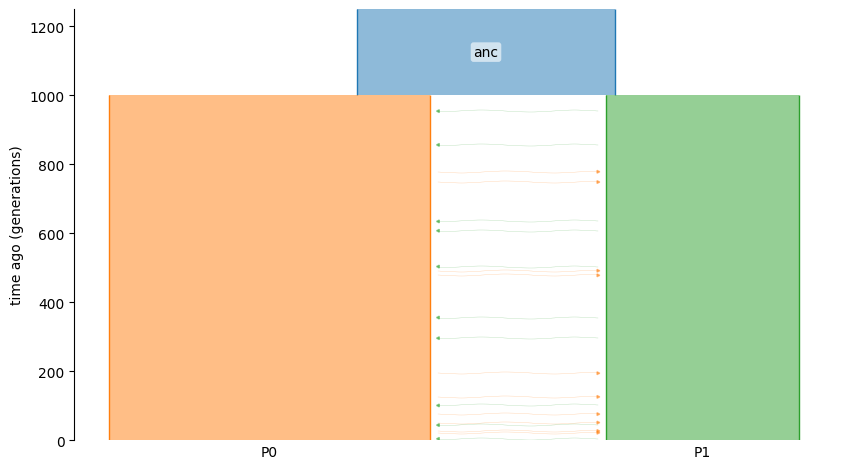

In [8]:
import msprime as msp
import demesdraw
import numpy as np

seed = 8
demo = msp.Demography()
demo.add_population(initial_size = 4000, name = "anc")
demo.add_population(initial_size = 5000, name = "P0")
demo.add_population(initial_size = 3000, name = "P1")
demo.set_symmetric_migration_rate(populations=("P0", "P1"), rate=1e-4)
tmp = [f"P{i}" for i in range(2)]
demo.add_population_split(time = 1000, derived=tmp, ancestral="anc")
g = demo.to_demes()
demesdraw.tubes(g)

sample_size = 50
samples = {f"P{i}": sample_size for i in range(2)}
anc = msp.sim_ancestry(samples=samples, demography=demo, recombination_rate=1e-8, sequence_length=1e8, random_seed = seed)
ts = msp.sim_mutations(anc, rate=1e-8, random_seed = seed*20)

In [15]:
num_populations = 2
fit_sample_size = 30
afs_samples = {f"P{i}": int(fit_sample_size*2) for i in range(num_populations)}
sample_sets = []
for i in range(num_populations):
    sample_sets.append(ts.samples([i+1])[0:2*fit_sample_size])
afs = ts.allele_frequency_spectrum(sample_sets=sample_sets, span_normalise=False, polarised=True)

analysis_type = "projection_multinomial"
projection = True

In [16]:
import numpy as np
from demestats.fit.util import create_constraints, modify_constraints_for_equality
import jax.numpy as jnp
from demestats.constr import constraints_for, EventTree
from loguru import logger
logger.disable("demestats")

et = EventTree(g)
# et.variables

In [17]:
import numpy as np
from demestats.fit.util import create_constraints, modify_constraints_for_equality
import jax.numpy as jnp
from demestats.constr import constraints_for, EventTree
from loguru import logger
logger.disable("demestats")

et = EventTree(g)

param_paths = [["migrations", 0, "rate"], ["migrations", 1, "rate"],
               ["demes", 1, "epochs", 0, "end_size"], ["demes", 2, "epochs", 0, "end_size"], 
              ['demes', 0, 'epochs', 0, 'end_time'], ["demes", 0, "epochs", 0, "end_size"]]
               # ["demes", 0, "epochs", 0, "end_time"]]
x0_bounds = [[0, 0.001], [0, 0.001],
            [500, 10000], [500, 10000], [100,1800], [500, 10000]] # [100, 1800]]

lb = np.array([0, 0, 500, 500, 50, 500]) # 50])
ub = np.array([0.001, 0.001, 1e8, 1e8, 1900, 1e8]) #1800])
index_to_remove = 5
symmetry_indices = [[0, 1]]

if analysis_type == "projection_multinomial" or analysis_type == "full_multinomial":
        param_paths = [item for i, item in enumerate(param_paths) if i != index_to_remove]
        x0_bounds = [item for i, item in enumerate(x0_bounds) if i != index_to_remove]
        sequence_length = None
        mutation_rate = None
        lb = jnp.delete(lb, index_to_remove)
        ub = jnp.delete(ub, index_to_remove)

np.random.seed(seed)
paths = {
    et.variable_for(tuple(path)): np.random.uniform(bounds[0], bounds[1])
    for path, bounds in zip(param_paths, x0_bounds)
}

target_key = frozenset({('migrations', 0, 'rate')})
source_key = frozenset({('migrations', 1, 'rate')})
paths[target_key] = paths[source_key]

constraint = create_constraints(g, paths)
constraint = modify_constraints_for_equality(constraint, symmetry_indices)

num_projections=150
theta=None

In [18]:
from typing import Any, List, Mapping, Set, Tuple
Path = Tuple[Any, ...]
Var = Path | Set[Path]
Params = Mapping[Var, float]

from demestats.fit.util import (
    _dict_to_vec,
    _vec_to_dict,
    _vec_to_dict_jax,
    create_inequalities,
    make_whitening_from_hessian,
    pullback_objective,
)
from demestats.loglik.sfs_loglik import (
    prepare_projection,
    projection_sfs_loglik,
    sfs_loglik,
)
from demestats.sfs import ExpectedSFS

path_order: List[Var] = list(paths)
x0 = _dict_to_vec(paths, path_order)
x0 = jnp.array(x0)
lb = jnp.array(lb)
ub = jnp.array(ub)
afs = jnp.array(afs)

esfs_obj = ExpectedSFS(demo.to_demes(), num_samples=afs_samples)

if projection:
    proj_dict, einsum_str, input_arrays = prepare_projection(
        afs, afs_samples, sequence_length, num_projections, seed
    )
else:
    proj_dict, einsum_str, input_arrays = None, None, None

args_nonstatic = (
    path_order,
    proj_dict,
    input_arrays,
    sequence_length,
    theta,
    projection,
    afs,
)
args_static = (esfs_obj, einsum_str)

/home/jkliang/demesinfer_updated_env/demesinfer_private/src/demestats/fit/util.py:38: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.asarray([d[k] for k in keys], dtype=jnp.float64)


In [19]:
import equinox as eqx
import jax
from demestats.fit.fit_sfs import _compute_sfs_likelihood
f = _compute_sfs_likelihood
def loglik_static(params, args_nonstatic):
    return f(params, args_nonstatic, args_static)

grad_f = eqx.filter_jit(jax.grad(loglik_static))
grad_value = grad_f(x0, args_nonstatic)
print(grad_value)

Params: [9.6854067e-04 9.6854067e-04 8.7573477e+03 5.5431289e+03 4.9563815e+02]
Loss: 23428536.0
[nan nan nan nan nan]
